# COURSE: A deep understanding of deep learning
## SECTION: CNN milestone projects
### LECTURE: Project 1
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [30]:
# import libraries 
import numpy as np 

import torch 
import torch.nn as nn
import torch.nn.functional as F

import torchvision

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

from torchsummary import summary

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [3]:
# use gpu 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [16]:
# Global variables 

BATCHSIZE = 64

# Import and inspect the data

In [9]:
cdata = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
cdata_valtest = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=None)
print(cdata)
print(cdata_valtest)
print(cdata.data.shape)

Files already downloaded and verified
Files already downloaded and verified
Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
(50000, 32, 32, 3)


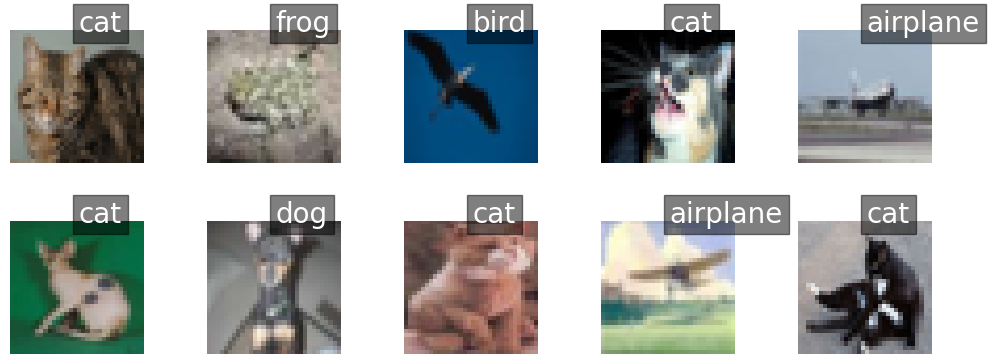

In [14]:
fig,axs = plt.subplots(2,5,figsize=(10,4))

for ax in axs.flatten():
    randidx = np.random.randint(0, len(cdata.data))

    pic = cdata.data[randidx,:,:,:]
    label = cdata.classes[cdata.targets[randidx]]

    ax.imshow(pic)
    ax.text(16,0, str(label), color='white', fontsize=20, bbox=dict(facecolor='black', alpha=0.5))
    ax.axis('off')

plt.tight_layout()
plt.show()


# Order the data, normalize it and put it in loaders

In [27]:
testdata, valdata, testlabels, vallabels = train_test_split(cdata_valtest.data, cdata_valtest.targets, test_size=0.5)

train_data_tensor = torch.tensor(cdata.data, dtype=torch.float32)
train_data_tensor = train_data_tensor.permute(0, 3, 1, 2) / 255.0 
train_labels_tensor = torch.tensor(cdata.targets, dtype=torch.long)

test_data_tensor = torch.tensor(testdata, dtype=torch.float32)
test_data_tensor = test_data_tensor.permute(0, 3, 1, 2) / 255.0
test_labels_tensor = torch.tensor(testlabels, dtype=torch.long)

val_data_tensor = torch.tensor(valdata, dtype=torch.float32)
val_data_tensor = val_data_tensor.permute(0, 3, 1, 2) / 255.0
val_labels_tensor = torch.tensor(vallabels, dtype=torch.long)

train_data = TensorDataset(train_data_tensor, train_labels_tensor)
test_data = TensorDataset(test_data_tensor, test_labels_tensor)
val_data = TensorDataset(val_data_tensor, val_labels_tensor)

batchsize = BATCHSIZE
train_loader = DataLoader(train_data, batch_size=batchsize, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0], shuffle=False, drop_last=True)
val_loader = DataLoader(val_data, batch_size=val_data.tensors[0].shape[0], shuffle=False, drop_last=True)

print(train_loader.dataset.tensors[0].shape)
print(train_loader.dataset.tensors[1].shape)
print(test_loader.dataset.tensors[0].shape)
print(test_loader.dataset.tensors[1].shape)
print(val_loader.dataset.tensors[0].shape)
print(val_loader.dataset.tensors[1].shape)

torch.Size([50000, 3, 32, 32])
torch.Size([50000])
torch.Size([5000, 3, 32, 32])
torch.Size([5000])
torch.Size([5000, 3, 32, 32])
torch.Size([5000])


# Create the model

In [ ]:
def makeTheNet():

    class cidar10net(nn.Module):
        def __init__(self):
            super().__init__()

            self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
            self.bnorm1 = nn.BatchNorm2d(64)
            #output = floor((32+2*1-3)/1) +1 = 32 / 2  = 16

            self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
            self.bnorm2 = nn.BatchNorm2d(128)
            #output = floor((16+2*1-3)/1) +1 = 16 / 2  = 8

            self.conv3  = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
            self.bnorm3 = nn.BatchNorm2d(256)
            #output = floor((8+2*1-3)/1) +1 = 8 / 2  = 4

            self.fc1 = nn.Linear(256*4*4, 512)
            self.bnorm4 = nn.BatchNorm1d(512)
            self.fc2 = nn.Linear(512, 10)

        def forward(self, x):
            self.ccn1 = F.leaky_relu(F.max_pool2d(self.bnorm1(self.conv1(x)), 2))
            self.ccn2 = F.leaky_relu(F.max_pool2d(self.bnorm2(self.conv2(self.ccn1)), 2))
            self.ccn3 = F.leaky_relu(F.max_pool2d(self.bnorm3(self.conv3(self.ccn2)), 2))
            
            #reshape
            nUnits = self.ccn3.shape.numel()/self.ccn3.shape[0] # number of values / number of batches
            x = self.ccn3.view(-1, int(nUnits)) # we need to reshape the data to be in a 2D array 

            x = F.leaky_relu(self.bnorm4(self.fc1(x)))
            x = self.fc2(x)

            return x
        
    net = cidar10net()
    
    lossfun = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

    return net, lossfun, optimizer

# Test the model

In [35]:
net, lossfun, optimizer = makeTheNet()
net.to(device)  # Move the model to the same device as the input tensor
print(net)

X, y = next(iter(train_loader))
X, y = X.to(device), y.to(device)  # Move input and labels to the same device
yHat = net(X)

print(yHat.shape)

loss = lossfun(yHat, torch.squeeze(y))
print(loss)

summary(net, (3, 32, 32), device=str(device))  # Ensure summary uses the correct device

cidar10net(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bnorm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bnorm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bnorm3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (bnorm4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)
torch.Size([64, 10])
tensor(2.3974, device='cuda:0', grad_fn=<NllLossBackward0>)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32] 

# Create a function that trains the model

In [38]:
def function2trainTheModel(epochs = 10, val=False):
    epochs = epochs

    net, lossfun, optimizer = makeTheNet()

    net.to(device)

    trainLoss = torch.zeros(epochs)
    testLoss = torch.zeros(epochs)
    valLoss = torch.zeros(epochs)
    trainAcc = torch.zeros(epochs)
    testAcc = torch.zeros(epochs)
    valAcc = torch.zeros(epochs)

    for epoch in range(epochs):
        net.train()

        batchLoss = []
        batchAcc = []
        
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            yHat = net(X)
            loss = lossfun(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchLoss.append(loss.item())
            batchAcc.append(torch.mean((torch.argmax(yHat, dim=1) == y).float()).item())

        trainLoss[epoch] = np.mean(batchLoss)
        trainAcc[epoch] = np.mean(batchAcc)

        net.eval()
        X,y = next(iter(test_loader))
        X, y = X.to(device), y.to(device)

        with torch.no_grad():
            yHat = net(X)
            loss = lossfun(yHat, y)

        testLoss[epoch] = loss.item()
        testAcc[epoch] = torch.mean((torch.argmax(yHat, dim=1) == y).float()).item()

        if val:
            X,y = next(iter(val_loader))
            X, y = X.to(device), y.to(device)

            with torch.no_grad():
                yHat = net(X)
                loss = lossfun(yHat, y)

            valLoss[epoch] = loss.item()
            valAcc[epoch] = torch.mean((torch.argmax(yHat, dim=1) == y).float()).item()

    return trainLoss, testLoss, valLoss, trainAcc, testAcc, valAcc



# Test the training function

In [40]:
trainLoss, testLoss, valLoss, trainAcc, testAcc, valAcc = function2trainTheModel(epochs=3, val=True)

# Train the model

In [42]:
trainLoss, testLoss, valLoss, trainAcc, testAcc, valAcc = function2trainTheModel(epochs=15, val=False)

# Graph the results

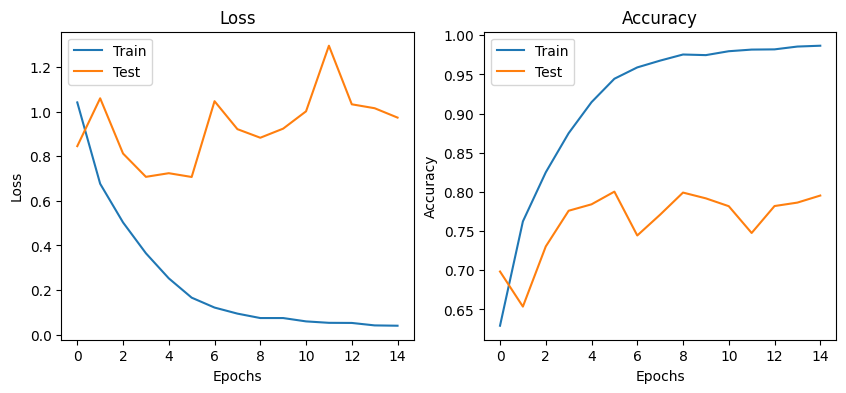

In [43]:
fix, axs = plt.subplots(1,2, figsize=(10,4))

axs[0].plot(trainLoss)
axs[0].plot(testLoss)
axs[0].set_title(f'Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend(['Train', 'Test'])

axs[1].plot(trainAcc)
axs[1].plot(testAcc)
axs[1].set_title(f'Accuracy')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend(['Train', 'Test'])

# Train the "final" model

In [44]:
# Initialize accumulators for averaging
avg_trainLoss = torch.zeros(20)
avg_testLoss = torch.zeros(20)
avg_valLoss = torch.zeros(20)
avg_trainAcc = torch.zeros(20)
avg_testAcc = torch.zeros(20)
avg_valAcc = torch.zeros(20)

# Loop 5 times
for _ in range(5):
    trainLoss, testLoss, valLoss, trainAcc, testAcc, valAcc = function2trainTheModel(epochs=20, val=True)
    avg_trainLoss += trainLoss
    avg_testLoss += testLoss
    avg_valLoss += valLoss
    avg_trainAcc += trainAcc
    avg_testAcc += testAcc
    avg_valAcc += valAcc

# Calculate the average
avg_trainLoss /= 5
avg_testLoss /= 5
avg_valLoss /= 5
avg_trainAcc /= 5
avg_testAcc /= 5
avg_valAcc /= 5

# Graph the results

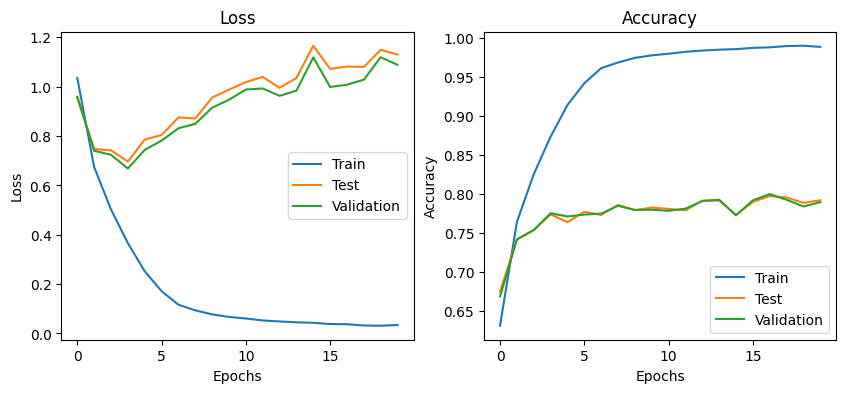

In [45]:
fix, axs = plt.subplots(1,2, figsize=(10,4))

axs[0].plot(avg_trainLoss)
axs[0].plot(avg_testLoss)
axs[0].plot(avg_valLoss)
axs[0].set_title(f'Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend(['Train', 'Test', 'Validation'])

axs[1].plot(avg_trainAcc)
axs[1].plot(avg_testAcc)
axs[1].plot(avg_valAcc)
axs[1].set_title(f'Accuracy')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend(['Train', 'Test', 'Validation'])